# 미션 설명 (📝 RAG 시스템 구현 미션 요약 및 가이드라인)

이 미션은 LangChain을 활용하여 LLM이 외부 문서(국세청 2024년 연말정산 신고 안내 문서)의 정보를 참고하여 답변을 생성할 수 있도록 **RAG(Retrieval-Augmented Generation) 시스템을 구현**하고 검증하는 것을 목표로 합니다.

---

### 🚀 핵심 목표 및 사용 데이터셋

| 구분 | 내용 |
| :--- | :--- |
| **미션 목표** | LangChain을 이용해 RAG 시스템 구현 후, 문서 기반 질문에 적절히 답변하는지 확인 |
| **사용 데이터셋** | 국세청 2024년 연말정산 신고 안내 문서 (연말정산 절차, 공제 항목, 개정 세법 등 포함) |

---

### 🛠️ RAG 시스템 구현 단계별 가이드라인

#### 1. 문서 로드 및 청킹 (Document Loading & Chunking)

* **목표:** 사용할 문서를 불러오고, 검색 효율을 위해 적절한 길이로 나눕니다.
* **고려 사항:**
    * 다양한 청킹 옵션 실험을 통해 최적의 설정을 찾습니다.
    * 단순 문자 수 대신, 문서의 **구조나 의미**를 고려하여 청킹할 수 있습니다.

#### 2. 임베딩 생성 및 벡터 데이터베이스 저장 (Embedding & Vector DB)

* **목표:** 각 청크에 임베딩을 생성하고, 검색을 위해 벡터 데이터베이스에 저장합니다.
* **고려 사항:**
    * **임베딩 모델 선정:** 특히 **한국어 문서**의 경우, 언어를 고려한 모델 선정에 따라 검색 성능이 크게 달라집니다 (Hugging Face 모델 활용).
    * **벡터 DB 선정:** 구현의 편의성 및 검색 성능을 고려하여 선택합니다 (예: FAISS, ChromaDB 등).

#### 3. 언어 모델 (LLM) 및 토크나이저 설정

* **목표:** RAG의 최종 답변을 생성할 LLM을 설정합니다.
* **고려 사항:**
    * **LLM 선정:** 한국어 질문 및 응답에 적합한 Hugging Face 모델을 선택합니다.
    * **최적화:** 필요한 경우 **양자화(Quantization)**를 통해 메모리 부하를 줄이고 응답 속도를 높입니다.
    * **생성 옵션:** `Temperature`, `Penalty` 등 텍스트 생성 관련 옵션을 적절히 설정하여 답변의 충실도를 높입니다.

#### 4. RAG 구현 및 성능 평가

* **목표:** 사용자의 질문에 대해 연관된 문서 청크를 검색하고(Retrieval), 이를 맥락(Context)으로 활용하여 답변을 생성하는(Generation) RAG 시스템을 완성합니다.
* **평가:**
    * 다양한 질문을 입력하고 **답변의 적절성 및 정확성**을 정성적으로 평가합니다.
    * **예시 질문:**
        * "연말 정산 때 비거주자가 주의할 점을 알려 줘."
        * "2024년 개정 세법 중에 월세와 관련한 내용이 있을까?"

---

# ①. API_RAG

1. 환경 설정
2. 문서 로드 (PyMuPDFLoader)
3. 텍스트 청킹 (Chunking)
4. OpenAI Embedding
5. Vector Store (FAISS)
6. 유사도 검색 테스트
7. OpenAI LLM 설정
8. RAG 체인 구성 (LCEL 방식)
9. RAG 시스템 테스트
10. 스트리밍 출력 (LCEL 장점)

## 1️⃣ 환경 설정

### **Part 2: OpenAI Embedding & LLM으로 RAG 구축**

LangChain 1.0+ 호환 버전 (LCEL 방식)

이번 실습에서는 **PyMuPDFLoader**로 문서를 로드하고, OpenAI의 Embedding과 LLM을 사용하여 완전한 RAG 시스템을 구축.

### **RAG 파이프라인 개요**


| 구성 요소 | 역할 |
| :---: | :--- |
| **PDF 문서** | PyMuPDFLoader를 통해 로드될 연구 자료 |
| **Chunking** | TextSplitter를 사용하여 문서를 의미 단위로 분할 |
| **Embedding** | OpenAI를 통해 텍스트를 벡터(수치)로 변환 |
| **Vector Store** | FAISS를 사용하여 벡터 저장 및 관리 |
| **Retriever** | 검색기 역할을 하며 Vector Store에서 관련 문서 검색 |
| **LLM** | GPT-4o-mini를 사용하여 검색된 문맥(Context) 기반으로 답변 생성 |
| **답변** | 사용자에게 최종 응답 제공 |


In [ ]:
### Environment Setup and Preparation (LangChain 1.0+)

!pip install -q pypdf langchain langchain-openai langchain-community faiss-cpu

In [ ]:
#### 1-1. Setting the OpenAI API Key
# 이 단계는 현재 사용 중인 LangChain의 버전을 확인하여, **LCEL(LangChain Expression Language) 방식**을 사용하는 데 문제가 없는지 검증합니다.
# 버젼 변경시 오류가 날 수 있음.

# 1. 버전 확인
import langchain
print(f"LangChain 버전: {langchain.__version__}")

LangChain 버전: 1.1.2


In [ ]:
#### 1-2. OpenAI API 키 설정

# OpenAI의 임베딩 및 LLM을 사용하기 위해 **API 키를 안전하게 입력**하는 단계입니다.
# 코랩(Colab) 환경에서 키가 노출되지 않도록 `getpass`를 사용하여 입력받는 방식이 가장 안전합니다.

# 2. OpenAI API 키 설정
import os
from getpass import getpass

# Colab에서 API 키 입력받기 (키를 환경 변수에 저장)
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key를 입력하세요: ")

OpenAI API Key를 입력하세요: ··········


In [ ]:
#### 1-3. 라이브러리 및 모듈 임포트 (LangChain 1.0+ 방식)

# RAG 파이프라인의 각 구성 요소(문서 로드, 청킹, 임베딩, 벡터 스토어, 프롬프트 등)를 사용하기 위해 필요한 핵심 모듈을 모두 불러옵니다.
# LCEL 체인을 구성하는 기반.

# 3. 라이브러리 및 모듈 임포트 (LangChain 1.0+ 방식)
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PDF_PATH = "/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
if not os.path.exists(PDF_PATH):
    raise FileNotFoundError(f"경로 오류: 지정된 경로에 파일이 없습니다. '{PDF_PATH}'")

## 2️⃣ 문서 로드 (PyMuPDFLoader)


## (1) Part 1: PDF 로더 비교 - PyPDF vs PyMuPDF**

RAG 시스템의 첫 번째 단계는 문서 로드입니다. PDF 문서를 텍스트로 변환하는 방식에 따라 후속 처리 품질이 달라집니다.

이번 실습에서는 LangChain에서 제공하는 두 가지 PDF 로더를 비교합니다:

| 라이브러리 | LangChain 클래스 | 특징 |
| :--- | :--- | :--- |
| **PyPDF** | `PyPDFLoader` | 순수 Python 기반, 가벼움, 기본적인 텍스트 추출 |
| **PyMuPDF** | `PyMuPDFLoader` | C 기반 바인딩, 빠름, 레이아웃 보존 우수 |

In [ ]:
#### **PyPDFLoader 사용 코드**

from langchain_community.document_loaders import PyMuPDFLoader, PyPDFLoader
import time
import os

# PyPDFLoader 사용
print("="*60)
print("📚 PyPDFLoader 로드 시작")
print("="*60)

start_time = time.time()
pypdf_loader = PyPDFLoader(PDF_PATH)
pypdf_docs = pypdf_loader.load()
pypdf_time = time.time() - start_time

print(f"\n로드 완료!")
print(f"✅ 총 페이지 수: {len(pypdf_docs)}")
print(f"⏳ 소요 시간: {pypdf_time:.2f}초")


📚 PyPDFLoader 로드 시작

로드 완료!
✅ 총 페이지 수: 426
⏳ 소요 시간: 44.85초


In [ ]:
# PyPDFLoader - Document 객체 구조 확인
sample_doc = pypdf_docs[0]
print("📝 Document 객체 구조")
print("-" * 40)
print(f"Type: {type(sample_doc)}")
print(f"\n메타데이터: {sample_doc.metadata}")
print(f"\n내용 (처음 300자):\n{sample_doc.page_content[:300]}")

📝 Document 객체 구조
----------------------------------------
Type: <class 'langchain_core.documents.base.Document'>

메타데이터: {'producer': 'ezPDF Builder Supreme', 'creator': 'PyPDF', 'creationdate': '2024-12-22T23:44:00+09:00', 'moddate': '2025-01-09T17:28:20+09:00', 'source': '/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf', 'total_pages': 426, 'page': 0, 'page_label': '1'}

내용 (처음 300자):
연말정산
신고안내
일 하나는 제대로 하는,
국민께 인정받는 국세청
2024. 12.
2024 원천징수의무자를 위한
맞춤형 안내
간소화 서비스
 일괄제공 서비스
발간등록번호
11-1210000-000072-10


In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 123.5 MB/s eta 0:00:00


In [ ]:
# 1. PyMuPDFLoader 사용
loader_pymupdf = PyMuPDFLoader(PDF_PATH)

# 2. 문서 로드 실행 및 변수명 수정
start_time = time.time()
# 주의: 결과를 'docs' 대신 'pymupdf_docs'에 저장합니다.
pymupdf_docs = loader_pymupdf.load()
end_time = time.time()
pymupdf_time = end_time - start_time

print(f"\n로드 완료!")
# 주의: 길이는 방금 로드한 'pymupdf_docs'의 길이를 출력합니다.
print(f"✅ 총 페이지 수: {len(pymupdf_docs)}")
print(f"⏳ 소요 시간: {pymupdf_time:.2f}초")


로드 완료!
✅ 총 페이지 수: 426
⏳ 소요 시간: 0.96초


In [ ]:
# 3. 로드 결과 확인
print(f"\n--- 문서 로드 결과 ---")
print(f"✔️ 로드된 문서 수 (페이지 수): {len(pymupdf_docs)}개")
print(f"✔️ 로드 시간: {end_time - start_time:.2f} 초")
print(f"✔️ 첫 번째 페이지의 내용 일부 (메타데이터 포함):")
print(pymupdf_docs[0])


--- 문서 로드 결과 ---
✔️ 로드된 문서 수 (페이지 수): 426개
✔️ 로드 시간: 0.96 초
✔️ 첫 번째 페이지의 내용 일부 (메타데이터 포함):
page_content='연말정산
신고안내
일 하나는 제대로 하는,
국민께 인정받는 국세청
2024. 12.
2
0
2
4
 
원
천
징
수
의
무
자
를
 
위
한
맞춤형 안내
간소화 서비스
일괄제공 서비스
발
간
등
록
번
호
11-1210000-000072-10' metadata={'producer': 'ezPDF Builder Supreme', 'creator': '', 'creationdate': '2024-12-22T23:44:00+09:00', 'source': '/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf', 'file_path': '/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf', 'total_pages': 426, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-01-09T17:28:20+09:00', 'trapped': '', 'modDate': "D:20250109172820+09'00'", 'creationDate': "D:20241222234400+09'00'", 'page': 0}


강사님 조언 → 페이지 8에는 표(Table) 형태의 데이터가 포함되어 있습니다. 두 로더가 표 구조를 어떻게 처리하는지 비교해봅시다.

In [ ]:
# Page 8 비교 (0-indexed이므로 index 7)
page_num = 8
idx = page_num - 1

In [ ]:
# 1. 라이브러리 임포트 및 로드
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
import time

# PDF_PATH 변수가 설정되어 있고 (예: "2024년_학회_연말정신_신고안내.pdf"),
# pypdf_docs와 pymupdf_docs가 이미 로드되었다고 가정합니다.
# 만약 로드하는 코드가 필요하다면 알려주세요.

# PyPDFLoader로 로드하는 예시 (실습 파일 경로에 맞게 조정하세요)
# loader_pypdf = PyPDFLoader(PDF_PATH)
# pypdf_docs = loader_pypdf.load()

# PyMuPDFLoader로 로드하는 예시
# loader_pymupdf = PyMuPDFLoader(PDF_PATH)
# pymupdf_docs = loader_pymupdf.load()


# 2. 비교 대상 페이지 인덱스 설정 (Page 8, 0-indexed는 7)
page_num = 8
idx = page_num - 1 # 7

print("=" * 70)
print(f"📌 Page {page_num} 비교: 표(Table) 처리 결과")
print("=" * 70)

# 3. PyPDFLoader 결과 출력
print(f"\n" + "🔵 PyPDFLoader 결과".center(70, "="))
pypdf_content = pypdf_docs[idx].page_content
print(pypdf_content)
print("-" * 70)
print(f"📄 PyPDFLoader 문자 수: {len(pypdf_content)}")


# 4. PyMuPDFLoader 결과 출력
print(f"\n" + "🟢 PyMuPDFLoader 결과".center(70, "="))
pymupdf_content = pymupdf_docs[idx].page_content
print(pymupdf_content)
print("-" * 70)
print(f"📄 PyMuPDFLoader 문자 수: {len(pymupdf_content)}")
print("=" * 70)

📌 Page 8 비교: 표(Table) 처리 결과

===========================🔵 PyPDFLoader 결과===========================
연말정산 소득·세액공제  
요건표
구 분
공 제 요 건
비 고
나이요건* 소득요건*
동거 요건
주민등록동거 일시퇴거 허용
기
본
공
제
본 인 × × ×
배 우 자 ×  ×
직계존속 60세 이상  △ 
(주거형편상 별거 허용) 1964.12.31. 이전
직계비속, 동거입양자 20세 이하  × 2004.  1.  1. 이후
장애인 직계비속의
장애인 배우자 ×  ×
형제자매 60세 이상
20세 이하    1964.12.31. 이전
2004.  1.  1. 이후
국민기초생활보장법에
의한 수급자 ×   
위탁아동 
추
가
공
제
장 애 인 기본공제대상자 중 장애인
경로우대 기본공제대상자 중 70세 이상인 자 1954.12.31.이전
부 녀 자 배우자가 없는 여성근로자로서 기본공제대상 부양가족이 있는 세대주 또는  
배우자가 있는 여성 근로자 (종합소득금액 3천만원 이하자)
한 부 모 배우자가 없는 자로서 부양자녀(20세 이하)가 있는자
연금보험료 공제 공적연금보험료의 근로자 본인 불입분만 공제 가능
* 나이요건    장애인의 경우 나이요건을 적용하지 않으며, 당해 과세기간 중 공제기준일이 해당하는 날이 있는 경우 적용
* 소득요건    연간 소득금액 100만원 이하(근로소득만 있는 경우 총급여 500만원 이하)
구 분
기본공제대상자의 요건 근로기간 지출한
비용만 공제 비 고
나이요건 소득요건
특별
소득공제
보 험 료 근로자 본인 부담분만 공제 가능 (건강·노인장기요양·고용보험료)
주택자금공제 - -  본인만 가능
그 밖의
소득공제
개인연금저축 근로자 본인 불입분만 공제 가능(배우자, 부양가족 불입분 제외)
주택마련저축 세대주인 근로자 본인 불입분만 공제 가능
신용카드 등 ×   형제자매 제외
자녀세액공제 (8세이상)   - 기본공제대상 자녀
(입양자·위탁아동·손자

In [ ]:
# 성능 및 품질 비교 요약
print(f"-"*70)
print(f"◼️ PyPDFLoader vs PyMuPDFLoader 비교 요약".center(70, " "))
print(f"-"*70)

print(f"{'항목':<20}{'PyPDFLoader':<20}{'PyMuPDFLoader':<20}")
print(f"-"*60)
print(f"{'로드 시간':<20}{pypdf_time:.2f}초{pymupdf_time:.2f}초")
print(f"{'속도 비율':<20}{'기준':<20}{pymupdf_time / pypdf_time:.1f}배 빠름")
print(f"{'Page 8 문자 수':<20}{len(pypdf_docs[7].page_content):<20}{len(pymupdf_docs[7].page_content):<20}")

----------------------------------------------------------------------
                ◼️ PyPDFLoader vs PyMuPDFLoader 비교 요약                 
----------------------------------------------------------------------
항목                  PyPDFLoader         PyMuPDFLoader       
------------------------------------------------------------
로드 시간               44.85초0.96초
속도 비율               기준                  0.0배 빠름
Page 8 문자 수         1196                1190                


In [ ]:
def compare_text_diff(text1, text2, label1="Text1", label2="Text2"):
    """두 텍스트의 차이점을 분석합니다."""
    # 공통 단어 / 고유 단어 분석
    words1 = set(text1.split())
    words2 = set(text2.split())

    common = words1 & words2
    only_in_1 = words1 - words2
    only_in_2 = words2 - words1

    print(f"\n단어 분석")
    print(f"- 공통 단어: {len(common)}개")
    print(f"- {label1}에만 있는 단어: {len(only_in_1)}개")
    print(f"- {label2}에만 있는 단어: {len(only_in_2)}개")

    # 일치율
    similarity = len(common) / max(len(words1), len(words2)) * 100
    print(f"- 단어 일치율: {similarity:.1f}%")

    return only_in_1, only_in_2

print(f"\n" + "==="*50)
print("Page 8 텍스트 차이 분석")
print("==="*50)
only_pypdf, only_pymupdf = compare_text_diff(
    pypdf_docs[7].page_content,
    pymupdf_docs[7].page_content,
    "PyPDF", "PyMuPDF"
)


Page 8 텍스트 차이 분석

단어 분석
- 공통 단어: 160개
- PyPDF에만 있는 단어: 2개
- PyMuPDF에만 있는 단어: 2개
- 단어 일치율: 98.8%


압도적인 속도 (35.7배 빠름): 연구 자료가 쌓여갈수록 로드 시간의 차이는 연구 효율성에 치명적인 영향을 미칩니다. 시간을 30배 이상 아낄 수 있다면, 그 시간을 연구 심화나 AI 역량 확장에 쓸 수 있습니다.

품질 분석의 중요성: 단순히 'PyMuPDF가 더 좋아 보인다'가 아니라, 단어 일치율이라는 정량적 지표를 통해 로더의 성능을 객관적으로 평가할 수 있게 해줍니다. (특히 표 데이터에서 단어가 꼬이는 현상을 고유 단어 개수로 확인할 수 있습니다.)

    * 결론적으로 시간차이는 크지만, 품질의 차이가 크게 없어서 Pymupdf를 사용하기로 함.

In [ ]:
# 1. PyMuPDFLoader 사용
loader_pymupdf = PyMuPDFLoader(PDF_PATH)

# 2. 문서 로드 실행 및 변수명 수정
start_time = time.time()
# 주의: 결과를 'docs' 대신 'pymupdf_docs'에 저장합니다.
documents = loader_pymupdf.load()
end_time = time.time()
pymupdf_time = end_time - start_time

print(f"\n로드 완료!")
# 주의: 길이는 방금 로드한 'pymupdf_docs'의 길이를 출력합니다.
print(f"✅ 총 페이지 수: {len(documents)}")
print(f"⏳ 소요 시간: {pymupdf_time:.2f}초")


로드 완료!
✅ 총 페이지 수: 426
⏳ 소요 시간: 0.80초


## 3️⃣ 텍스트 청킹 (Chunking)

1. 청킹(Chunking)은 왜 필요한가?
- 긴 문서를 통째로 넣으면 LLM이 처리하지 못하거나 성능이 떨어지기 때문에, 의미 있는 작은 단위로 자르는 과정입니다.
- Context Window 제한 극복: 모델이 한 번에 읽을 수 있는 토큰(글자 수) 한계를 넘지 않기 위해 필요합니다.
- 검색 정확도 향상: 사용자의 질문과 가장 관련성 높은 '특정 부분'만 정확히 찾아내기 위해 작은 단위가 유리합니다.
- 임베딩 품질: 텍스트가 너무 길면 여러 주제가 섞여 벡터(의미) 표현이 모호해지므로, 적절한 길이로 잘라야 의미가 명확해집니다.

2. Why is Chunking Necessary?
- Sequential Separators: It attempts to split text using a list of separators in a specific order: \n\n (double newline), \n (newline), (space), and "" (empty string).
- Preserving Boundaries: The goal is to keep related text (like sentences or paragraphs) together as much as possible to maintain semantic context.
- Effective for Korean: It is particularly effective for Korean documents where context preservation is critical.

In [ ]:
# RecursiveCharacterTextSplitter (재귀적 문자 텍스트 분할기)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,    # 하나의 청크당 최대 글자 수 (1000자)
    chunk_overlap=200,  # 청크 간 겹치는 구간 (200자) - 문맥 단절 방지
    length_function=len,
    separators=["\n\n", "\n", " ", ""] # 우선순위대로 자르는 기준
)

In [ ]:
# Execute Document Splitting
print("\n" + "="*60)
print("Chunking documents...")
print("="*60)

start_time = time.time()
chunks = text_splitter.split_documents(documents) #
chunk_time = time.time() - start_time

print(f"\nChunking Complete!")
# Original Docs: {count} -> Chunks: {count}
print(f"Original Documents: {len(documents)} -> Chunks: {len(chunks)}")
# Avg chunks/page
print(f"Average chunks per page: {len(chunks)/len(documents):.1f}")
print(f"Time elapsed: {chunk_time:.2f} seconds")


Chunking documents...

Chunking Complete!
Original Documents: 426 -> Chunks: 634
Average chunks per page: 1.5
Time elapsed: 0.03 seconds


In [ ]:
# Sample Check (10번째 청크)
print("Sample Check (10th Chunk)")
print("-" * 50)
sample_chunk = chunks[10]
print(f"MetaData: {sample_chunk.metadata}") # 출처, 페이지 번호 등 확인
print(f"\nMaterials ({len(sample_chunk.page_content)}자):")
print(sample_chunk.page_content)

Sample Check (10th Chunk)
--------------------------------------------------
MetaData: {'producer': 'ezPDF Builder Supreme', 'creator': '', 'creationdate': '2024-12-22T23:44:00+09:00', 'source': '/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf', 'file_path': '/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf', 'total_pages': 426, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-01-09T17:28:20+09:00', 'trapped': '', 'modDate': "D:20250109172820+09'00'", 'creationDate': "D:20241222234400+09'00'", 'page': 5}

Materials (191자):
등록된 자를 위해 지출한 의료비, 난임시술비는 한도 없음
※ 산후조리원비용 : 출산 1회당 200만원 한도
※ 장애인활동지원급여* 비용 중 실제 지출한 본인부담금
* 「장애인활동 지원에 관한 법률」에 따라 수급자에게 제공되는 활동보조, 방문목욕, 방문간호 등 서비스
과세표준
산출세액
(-) ‌세액감면 및 
세액공제
(x) 기본세율
146P


In [ ]:
# 청크 크기 분포 확인
chunk_sizes = [len(chunk.page_content) for chunk in chunks]

print("청크 크기 통계")
print(f" - 최소: {min(chunk_sizes)}자")
print(f" - 최대: {max(chunk_sizes)}자")
print(f" - 평균: {sum(chunk_sizes)/len(chunk_sizes):.0f}자")

청크 크기 통계
 - 최소: 3자
 - 최대: 1000자
 - 평균: 681자


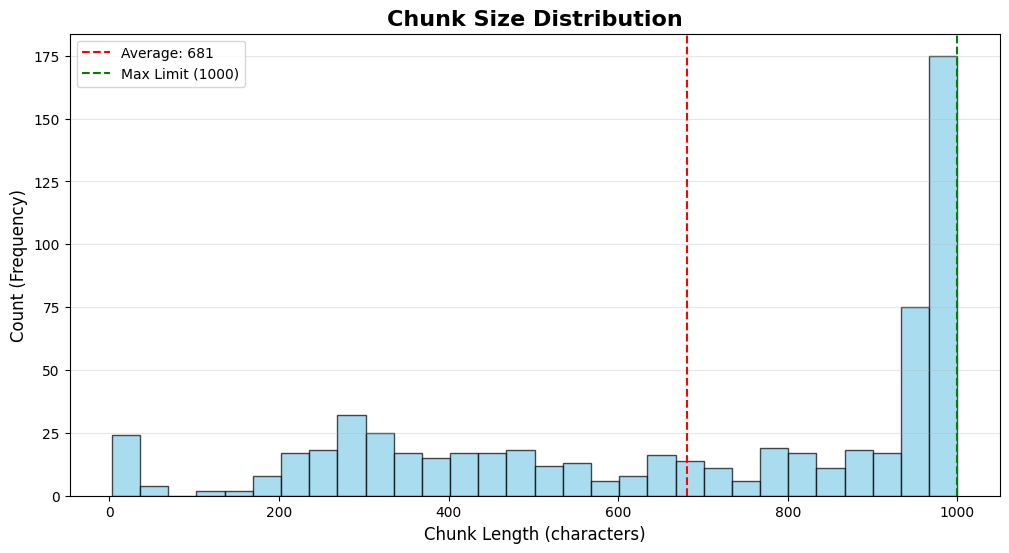

In [ ]:
import matplotlib.pyplot as plt

# 이전 단계에서 계산된 chunk_sizes 리스트를 사용합니다
# chunk_sizes = [len(chunk.page_content) for chunk in chunks]

plt.figure(figsize=(12, 6))

# 히스토그램 그리기 (bins는 막대의 개수입니다)
plt.hist(chunk_sizes, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# 평균값 표시선 추가 (빨간 점선)
avg_size = sum(chunk_sizes) / len(chunk_sizes)
plt.axvline(avg_size, color='red', linestyle='dashed', linewidth=1.5, label=f'Average: {avg_size:.0f}')

# 최대 설정값(1000자) 표시선 추가 (녹색 점선)
plt.axvline(1000, color='green', linestyle='dashed', linewidth=1.5, label='Max Limit (1000)')

# 차트 꾸미기
plt.title('Chunk Size Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Chunk Length (characters)', fontsize=12)
plt.ylabel('Count (Frequency)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 그래프 출력
plt.show()

In [ ]:
# 1. 50자 미만 청크만 따로 모아서 확인 (Inspection)
small_chunks = [chunk for chunk in chunks if len(chunk.page_content) < 50]

print(f"🔍 50자 미만 청크 발견: 총 {len(small_chunks)}개")
print("=" * 60)

for i, chunk in enumerate(small_chunks):
    print(f"[{i+1}] (길이: {len(chunk.page_content)}자) : {repr(chunk.page_content)}")

print("=" * 60)

🔍 50자 미만 청크 발견: 총 26개
[1] (길이: 13자) : '제2부\n근로소득\n연말정산'
[2] (길이: 24자) : '제3부\n연말정산 \n종합사례 및\n서식 작성방법'
[3] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n255'
[4] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n256'
[5] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n257'
[6] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n258'
[7] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n259'
[8] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n260'
[9] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n261'
[10] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n262'
[11] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n264'
[12] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n265'
[13] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n266'
[14] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n267'
[15] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n268'
[16] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n269'
[17] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n270'
[18] (길이: 32자) : 'Ⅳ. 수정 원천징수이행상황신고서 작성사례(과다공제)\n271'
[19] (길이: 32자) : '원천징수의무자를 위한 \n2024년 연말정산 신고안내\n

In [ ]:
chunks = [chunk for chunk in chunks if len(chunk.page_content) >= 50]

## 4️⃣ OpenAI Embedding
-> 이건 책장에 붙일 번호와 같은 개념!

**OpenAI Embedding 모델**

| 모델 | 차원 | 특징 |
| :--- | :--- | :--- |
| `text-embedding-3-small` | 1536 | 빠르고 저렴, 대부분의 용도에 적합 |
| `text-embedding-3-large` | 3072 | 더 정확, 복잡한 검색에 유리 |

<br>


In [ ]:
pip install langchain-openai

In [ ]:
from langchain_openai import OpenAIEmbeddings

# OpenAI Embedding 모델 초기화
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small" # 비용 효율적인 모델 선택
)

print("OpenAI Embedding 모델 초기화 완료")
print(f" - 모델: text-embedding-3-small")
print(f" - 차원: 1536")

OpenAI Embedding 모델 초기화 완료
 - 모델: text-embedding-3-small
 - 차원: 1536


In [ ]:
# Embedding 테스트
test_text = "연말정산 의료비 공제 한도는 얼마인가요?"
test_embedding = embeddings.embed_query(test_text)

print("Embedding 테스트")
print(f" - 입력 텍스트: '{test_text}'")
print(f" - 벡터 차원: {len(test_embedding)}")
print(f" - 벡터 샘플 (처음 5개): {test_embedding[:5]}")

Embedding 테스트
 - 입력 텍스트: '연말정산 의료비 공제 한도는 얼마인가요?'
 - 벡터 차원: 1536
 - 벡터 샘플 (처음 5개): [0.005206627305597067, -0.053752630949020386, 0.01164640299975872, 0.025548309087753296, -0.024578653275966644]


뒤에 벡터가 1536개ㅏ 더있다!

## 5️⃣ Vector Store (FAISS)


-----

이전 단계에서 만든 '1536개의 숫자들'을 그냥 리스트에 담아두면 검색이 너무 느리기 때문에, **FAISS**라는 고속 검색 엔진에 넣는 과정입니다.

**FAISS:**

  * Facebook AI Similarity Search
  * 대규모 벡터 유사도 검색을 위한 라이브러리
  * 로컬에서 실행 가능 (서버 불필요)
  * 빠른 검색 속도

**다른 Vector Store 옵션**

| Vector Store | 특징 |
| :--- | :--- |
| **FAISS** | 로컬, 빠름, 설치 간단 |
| **Chroma** | 로컬, 영구 저장, 메타데이터 필터링 |
| **Pinecone** | 클라우드, 확장성, 관리형 |


In [ ]:
import time
from langchain_community.vectorstores import FAISS

# FAISS Vector Store 생성
print("="*60)
print("FAISS Vector Store 생성 중...")
print("="*60)
print(f"\n임베딩할 청크 수: {len(chunks)}개") # chunks 변수가 정의되어 있어야 함

start_time = time.time()
vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

embed_time = time.time() - start_time

print(f"\nVector Store 생성 완료!")
print(f"소요 시간: {embed_time:.2f}초")
print(f"처리 속도: {len(chunks)/embed_time:.1f} 청크/초")

FAISS Vector Store 생성 중...

임베딩할 청크 수: 608개

Vector Store 생성 완료!
소요 시간: 11.42초
처리 속도: 53.3 청크/초


## 6️⃣ 유사도 검색 테스트
- Rag 체인 구성하기전, 검색이 잘 작동하는지 Test해보자

- Logic:

    - Vectorization: Convert the query (e.g., "Medical expenses...") into vector coordinates.

    - Distance Calculation: Calculate the distances between the query vector and all stored data coordinates.

    - Selection: Retrieve the top 3 (k=3) data points based on the closest proximity.

In [ ]:
# 유사도 검색 테스트
query = "의료비 세액공제 한도"

print(f"검색 쿼리: '{query}'")
print("="*60)

# 상위 3개 문서 검색
similar_docs = vectorstore.similarity_search(query, k=3)

for i, doc in enumerate(similar_docs, 1):
    print(f"\n결과 {i} (페이지: {doc.metadata.get('page', 'N/A')})")
    print("-"*50)
    print(doc.page_content[:400] + "...")

검색 쿼리: '의료비 세액공제 한도'

결과 1 (페이지: 231)
--------------------------------------------------
공제대상
체험학습비
기타 자료
50만원
공제대상(30만원)
수능응시료
국세청 자료
20만원
공제대상
학원비
-
120만원
공제대상 아님
이강모
대학원 수강료(비과세학자금)
-
300만원
공제대상 아님
＊교육비 세액공제 ⇨ 630,000원
  
구분
공제대상
공제대상 제외
공제 한도
세액공제 대상금액
세액공제액
취학전아동
120만원
300만원
120만원
630,000
고등학생
335만원
120만원
300만원
300만원
근로자 본인
300만원
없음
-
합계
455만원
420만원
420만원
  ※ 세액공제액 계산：세액공제 대상금액(4,200,000원) × 15% = 630,000원...

결과 2 (페이지: 231)
--------------------------------------------------
원천징수의무자를 위한 
2024년 연말정산 신고안내
216
○ 의료비 세액공제
＊의료비 세액공제 ⇨ 950,700원
  
구분
수술
입원치료비
시력교정용안경
산후조리원 비용
세액공제
대상금액
세액공제액
본인,
난임시술비
230만원*
55만원 →
50만원한도
280.0만원
950,700원
그 외
부양가족
250만원
220만원 →
한도 200만원
253.8만원
합계
250만원
230만원
50만원
200만원
533.8만원
＊입원치료비 130만원, 난임시술비 100만원
국세청자료
250만원
230만원
200만원
기타 자료
50만원
  ＊시력교정용 안경을 제외하고 나머지는 국세청자료에 해당
    - 세액공제 대상금액 계산：5,338,000원 (②+③+④)
      ① 총급여액의 3% → 1,962,000원 (65...

결과 3 (페이지: 4)
--------------------------------------------------
총급여액의 25%를 초과하는 금액의 15%~40%를 소득공제
* ‌공제한도 :

## 7️⃣ OpenAI LLM 설정

**GPT 모델 선택 가이드**

| 모델 | 특징 | 비용 (1M tokens) |
| :--- | :--- | :--- |
| gpt-4o | 최신, 가장 강력 | 2.50 / 10 |
| gpt-4o-mini | 빠르고 저렴, 대부분 충분 | 0.15 / 0.60 |
| gpt-4-turbo | 긴 컨텍스트 (128K) | 10 / 30 |

In [ ]:
# OpenAI LLM 초기화
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,          # 일관된 답변을 위해 0으로 설정
    max_tokens=1000         # 최대 출력 토큰
)

print("OpenAI LLM 초기화 완료")
print(f" - 모델: gpt-4o-mini")
print(f" - temperature: 0")
print(f" - max_tokens: 1000")

OpenAI LLM 초기화 완료
 - 모델: gpt-4o-mini
 - temperature: 0
 - max_tokens: 1000


In [ ]:
# LLM 테스트
response = llm.invoke("안녕하세요, 간단히 자기소개 해주세요.")
print("LLM 테스트 응답:")
print(response.content)

LLM 테스트 응답:
안녕하세요! 저는 AI 언어 모델로, 다양한 주제에 대해 정보를 제공하고 질문에 답변하는 역할을 하고 있습니다. 여러분의 궁금증을 해결하고, 필요한 정보를 찾는 데 도움을 드리기 위해 여기 있습니다. 어떤 질문이든 편하게 해주세요!


## 8️⃣ RAG 체인 구성 (LCEL 방식)

**LangChain Expression Language (LCEL)**
LangChain 1.0에서는 LCEL을 사용하여 체인을 구성합니다.
**책장(Vectorstore)**을 **질문에 따라 책을 꺼내줄 수 있는 '검색 시스템(Retriever)'**으로 만드는 것

    chain = (
        {"context": retriever,
        "question": RunnablePassThrough()}
         | prompt
         | llm
         | StrOutputParser()
    )

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity", # 유사도 검색
    search_kwargs={"k": 4}    # 상위 4개 문서 검색
)

In [ ]:
# 프롬프트 템플릿
template = """
당신은 한국 세법 전문가입니다.
주어진 문서 내용을 바탕으로 질문에 정확하게 답변해주세요.

문서에 답변이 없는 경우, "제공된 문서에서 해당 정보를 찾을 수 없습니다"라고 답변하세요.
추측하지 말고, 문서에 있는 내용만 답변하세요.

참고 문서:
{context}

질문: {question}

답변:
"""

prompt = ChatPromptTemplate.from_template(template)

print("프롬프트 템플릿 설정 완료")

프롬프트 템플릿 설정 완료


In [ ]:
# 프롬프트 템플릿 (Rag에서는 항상 두가지가 같이 가야해. {질문}, {Vector DB에서 나온 결과})
template = """
당신은 기밀문서에 대해 전문적으로 답변을 내어줄 수 있는 한국 세법 전문가입니다.
주어진 문서 내용을 바탕으로 질문에 정확하게 답변해주세요.

- 문서에 답변이 없다면, "제공된 문서에서 해당 정보를 찾을 수 없습니다"라고 답변하세요.
- 추측하지 말 것. 문서에 있는 내용만으로 답변할 것.

참고 문서:
{context}

질문: {question}

답변:
"""

prompt = ChatPromptTemplate.from_template(template)

print("프롬프트 템플릿 설정 완료")

프롬프트 템플릿 설정 완료


In [ ]:
def format_docs(docs):
    """검색된 문서들을 하나의 문자열로 포맷팅"""
    return "\n\n".join([
        f"페이지: {doc.metadata.get('page', 'N/A')}\n{doc.page_content}"
        for doc in docs
    ])

print("문서 포맷팅 함수 정의 완료")

문서 포맷팅 함수 정의 완료


In [ ]:
# LCEL 방식으로 RAG 체인 구성
rag_chain = (
    {
        "context": retriever | format_docs,  # 검색 -> 포맷팅 (위에 우리가 설정)
        "question": RunnablePassthrough()    # 질문 그대로 전달 (질문을 바꾸고 싶다면, Runnablelambda)
    }
    | prompt                              # 프롬프트 적용
    | llm                                 # LLM 호출
    | StrOutputParser()                   # 문자열로 파싱
)

print("RAG 체인 구성 완료! (LCEL 방식)")
print("\n체인 구성:")
print("Query -> Retriever -> format_docs -> Prompt -> LLM -> Output")

RAG 체인 구성 완료! (LCEL 방식)

체인 구성:
Query -> Retriever -> format_docs -> Prompt -> LLM -> Output


Query -> 시스템에게 던지는 질문

## 9️⃣ RAG 시스템 테스트

In [ ]:
def ask_question(question):
    """RAG 시스템에 질문하고 결과를 출력합니다."""
    print("="*70)
    print(f"질문: {question}")
    print("="*70)

    start_time = time.time()

    # LCEL 체인 실행
    answer = rag_chain.invoke(question)

    response_time = time.time() - start_time

    print(f"\n답변:")
    print(answer)

    # 참고 문서 조회
    source_docs = retriever.invoke(question)
    print(f"\n참조 문서 ({len(source_docs)}개):")
    for i, doc in enumerate(source_docs, 1):
        page = doc.metadata.get('page', 'N/A')
        print(f" - {i}. 페이지 {page}: {doc.page_content[:80]}...")

    print(f"\n응답 시간: {response_time:.2f}초")
    print("\n")

    return answer

In [ ]:
# 테스트 질문 1: 의료비 공제
result1 = ask_question("의료비 세액공제 한도는 얼마인가요?")

질문: 의료비 세액공제 한도는 얼마인가요?

답변:
제공된 문서에서 해당 정보를 찾을 수 없습니다.

참조 문서 (4개):
 - 1. 페이지 231: 공제대상
체험학습비
기타 자료
50만원
공제대상(30만원)
수능응시료
국세청 자료
20만원
공제대상
학원비
-
120만원
공제대상 아님
이강모
...
 - 2. 페이지 230: Ⅰ. 2024년 귀속 연말정산 종합사례
215
사. 세액공제 및 세액감면
○ 근로소득세액공제
＊근로소득세액공제 ⇨ 660,000원 = MIN(①...
 - 3. 페이지 4: 총급여액의 25%를 초과하는 금액의 15%~40%를 소득공제
* ‌공제한도 : 총급여 7천만원 이하는 300만원, 총급여 7천만원 초과는 25...
 - 4. 페이지 231: 원천징수의무자를 위한 
2024년 연말정산 신고안내
216
○ 의료비 세액공제
＊의료비 세액공제 ⇨ 950,700원
  
구분
수술
입원치료비
...

응답 시간: 3.58초




In [ ]:
# 테스트 질문 2: 연장근로 수당
Result2 = ask_question("연장근로수당은 어떻게 계산하나요?")

질문: 연장근로수당은 어떻게 계산하나요?

답변:
제공된 문서에서 해당 정보를 찾을 수 없습니다.

참조 문서 (4개):
 - 1. 페이지 423: 원천징수의무자를 위한 
2024년 연말정산 신고안내
408
근로소득·사업소득·연금소득 연말정산 비교
구분
근로소득
사업소득
연금소득
1. 연말정...
 - 2. 페이지 417: 총액에서 ｢근로기준법｣에 따른 연장근로·야간근로 또는 휴일근로를 
하여 통상임금에 더하여 받는 급여 및 ｢선원법｣에 따라 받는 생산수당
(비율급...
 - 3. 페이지 153: 원천징수의무자를 위한 
2024년 연말정산 신고안내
138
○우리사주조합은 우리사주조합원의 출연금 중 소득공제의 대상이 되는 금액과 그러하지 아...
 - 4. 페이지 88: Ⅰ. 근로소득
73
○｢국군포로의 송환 및 대우 등에 관한 법률｣에 따른 국군포로가 지급받는 보수 및 퇴직일시금
○｢교육기본법｣ 제28조 제1항...

응답 시간: 3.09초




In [ ]:
# 테스트 질문 3: 식사대 비과세
result3 = ask_question("식사대 비과세 요건을 알려주세요")

질문: 식사대 비과세 요건을 알려주세요

답변:
식사대 비과세 요건은 다음과 같습니다:

1) 현물 식사
   - 근로자가 사내급식 또는 이와 유사한 방법으로 제공받는 식사 기타 음식물은 비과세합니다. 비과세되는 식사·기타 음식물은 사용자가 무상으로 제공하는 음식물로서 다음의 요건에 해당해야 합니다.
     - 통상적으로 급여에 포함되지 아니함
     - 음식물의 제공 여부로 급여에 차등이 없음
     - 사용자가 추가 부담하여 제공

2) 월 20만원 이하 식사대
   - 식사·기타 음식물을 제공받지 아니하는 근로자가 받는 월 20만원 이하 식사대는 비과세되는 근로소득에 해당합니다. 

또한, 회사로부터 음식물을 제공받지 아니하고 식사대로 매월 25만원을 지급받는 경우, 20만원은 비과세하고 5만원은 과세됩니다.

참조 문서 (4개):
 - 1. 페이지 84: ○식사·기타 음식물을 제공받고 있는 근로자가 별도로 식사대를 지급받는 경우에는 제공받은식사·
기타 음식물에 한하여 비과세되는 급여로 본다. 다만...
 - 2. 페이지 82: ① 기본급 140만원
⑤ 야간근로수당 10만원
    ② 가족수당(매월 지급) 6만원
⑥ 휴일근로수당 5만원
    ③ 상여 100만원
⑦ 식대...
 - 3. 페이지 83: 원천징수의무자를 위한 
2024년 연말정산 신고안내
68
   
참고
통상임금에 가산하여 지급받는 급여의 범위
근로기준법 제56조【연장·야간 및...
 - 4. 페이지 84: Ⅰ. 근로소득
69
   - 통상적으로 급여에 포함되지 아니함
   - 음식물의 제공 여부로 급여에 차등이 없음
   - 사용자가 추가 부담하여...

응답 시간: 6.88초




## 🔟 스트리밍 출력 (LCEL 장점)
    - 답변이 시간이 오래걸린다면, 이러한 기능을 킬 수 도 있다!



In [ ]:
# 스트리밍 출력 테스트
question = "연말정산 시 교육비 공제 대상은 무엇인가요?"

print(f"질문: {question}")
print("="*60)
print("\n답변 (스트리밍):")

# stream() 메서드로 스트리밍 출력
for chunk in rag_chain.stream(question): # 답변은 똑같아도 일을 하고 있구나를 볼 수 있어 좋음!
    print(chunk, end="", flush=True)

print("\n")

질문: 연말정산 시 교육비 공제 대상은 무엇인가요?

답변 (스트리밍):
연말정산 시 교육비 공제 대상은 다음과 같습니다:

1. **근로자 본인을 위하여 지급한 교육비**:
   - ｢유아교육법｣, ｢초·중등교육법｣, ｢고등교육법｣ 및 ｢특별법｣에 따른 학교(국외교육기관 포함)
   - ｢평생교육법｣에 따른 고등학교졸업 이하의 학력이 인정되는 학교형태의 평생 교육시설, 전공대학, 원격대학

2. **기본공제대상자(나이 제한 없음)**인 배우자, 직계비속, 형제자매 및 입양자를 위한 교육비:
   - 초등학교 취학 전 아동, 초·중·고등학생: 1명당 연 300만원 한도 적용
   - 대학생: 1명당 연 900만원 한도 적용
   - 대학원생: 공제대상 아님

3. **장애인 특수교육비(직계존속 포함)**: 전액

4. **장애인의 재활교육을 위한 비용**: 사회복지시설 및 비영리법인에 지출한 비용 전액, 18세 미만인 기본공제대상 장애인의 기능향상과 행동발달을 위한 발달재활서비스 제공기관에 지출한 비용 전액

단, 교육비 세액공제 대상에서 제외되는 항목도 있으며, 이는 비과세되는 교육비 등입니다.



# ②. Hugging face 로 구현

In [ ]:
# 라이브러리 설치 (실행 중 설정이 바뀔 수 있는 패키지)
!pip install -q pymupdf langchain-huggingface langchain-community faiss-cpu
!pip install -q sentence-transformers transformers accelerate bitsandbytes

PyMuPDFLoader로 문서를 로드하고, HuggingFace 모델을 로컬 GPU에서 실행하여 RAG 시스템을 구축합니다.

### RAG 파이프라인 개요

* **1단계: 문서 처리 및 저장**
    * PDF 문서 $\rightarrow$ PyMuPDFLoader
    * $\rightarrow$ Chunking (TextSplitter)
    * $\rightarrow$ Embedding (HuggingFace 로컬)
    * $\rightarrow$ Vector Store (FAISS)
* **2단계: 질의응답**
    * Vector Store (FAISS)
    * $\rightarrow$ Retriever (검색기)
    * $\rightarrow$ LLM (로컬)
    * $\rightarrow$ 답변

### Inference API vs 로컬 실행 비교

| 항목 | Inference API | 로컬 실행 |
| :--- | :--- | :--- |
| **API 키** | 필요 | 불필요 |
| **비용** | 유료 (특정 건 제한) | 완전 무료 |
| **속도** | 네트워크 의존 | GPU 성능 의존 |
| **GPU** | 불필요 | 필요 (VRAM $\ge 14\text{GB}$) |
| **모델 변경** | 불가 | 가능 |

## 1️⃣ 환경설정


In [ ]:
#GPU Check

!nvidia-smi

Fri Dec 12 00:45:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   52C    P8             17W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 이전 확인
import torch
import langchain

print(f"LangChain 버전: {langchain.__version__}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

LangChain 버전: 1.1.2
PyTorch 버전: 2.9.0+cu126
CUDA 사용 가능: True
GPU: NVIDIA L4
VRAM: 22.2 GB


In [ ]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline # transformers 추가
import torch
import time

## 2️⃣ 문서로드


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PDF_PATH = "/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. PyMuPDFLoader 사용
loader_pymupdf = PyMuPDFLoader(PDF_PATH)

# 2. 문서 로드 실행 및 변수명 수정
start_time = time.time()
# 주의: 결과를 'docs' 대신 'pymupdf_docs'에 저장합니다.
documents = loader_pymupdf.load()
end_time = time.time()
pymupdf_time = end_time - start_time

print(f"\n로드 완료!")
# 주의: 길이는 방금 로드한 'pymupdf_docs'의 길이를 출력합니다.
print(f"✅ 총 페이지 수: {len(documents)}")
print(f"⏳ 소요 시간: {pymupdf_time:.2f}초")


로드 완료!
✅ 총 페이지 수: 426
⏳ 소요 시간: 1.38초


## 3️⃣ Chunking

In [ ]:
# RecursiveCharacterTextSplitter (재귀적 문자 텍스트 분할기)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,    # 하나의 청크당 최대 글자 수 (1000자)
    chunk_overlap=200,  # 청크 간 겹치는 구간 (200자) - 문맥 단절 방지
    length_function=len,
    separators=["\n\n", "\n", " ", ""] # 우선순위대로 자르는 기준
)

In [ ]:
# Execute Document Splitting
print("\n" + "="*60)
print("Chunking documents...")
print("="*60)

start_time = time.time()
chunks = text_splitter.split_documents(documents) #
chunk_time = time.time() - start_time

print(f"\nChunking Complete!")
# Original Docs: {count} -> Chunks: {count}
print(f"Original Documents: {len(documents)} -> Chunks: {len(chunks)}")
# Avg chunks/page
print(f"Average chunks per page: {len(chunks)/len(documents):.1f}")
print(f"Time elapsed: {chunk_time:.2f} seconds")


Chunking documents...

Chunking Complete!
Original Documents: 426 -> Chunks: 634
Average chunks per page: 1.5
Time elapsed: 0.03 seconds


In [ ]:
# Sample Check (10번째 청크)
print("Sample Check (10th Chunk)")
print("-" * 50)
sample_chunk = chunks[10]
print(f"MetaData: {sample_chunk.metadata}") # 출처, 페이지 번호 등 확인
print(f"\nMaterials ({len(sample_chunk.page_content)}자):")
print(sample_chunk.page_content)

Sample Check (10th Chunk)
--------------------------------------------------
MetaData: {'producer': 'ezPDF Builder Supreme', 'creator': '', 'creationdate': '2024-12-22T23:44:00+09:00', 'source': '/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf', 'file_path': '/content/drive/MyDrive/미션 스프린트/미션 14/2024년+원천징수의무자를+위한+연말정산+신고안내.pdf', 'total_pages': 426, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-01-09T17:28:20+09:00', 'trapped': '', 'modDate': "D:20250109172820+09'00'", 'creationDate': "D:20241222234400+09'00'", 'page': 5}

Materials (191자):
등록된 자를 위해 지출한 의료비, 난임시술비는 한도 없음
※ 산후조리원비용 : 출산 1회당 200만원 한도
※ 장애인활동지원급여* 비용 중 실제 지출한 본인부담금
* 「장애인활동 지원에 관한 법률」에 따라 수급자에게 제공되는 활동보조, 방문목욕, 방문간호 등 서비스
과세표준
산출세액
(-) ‌세액감면 및 
세액공제
(x) 기본세율
146P


## 4️⃣ HuggingFace Embedding (로컬 실행)

In [ ]:
# HuggingFace Embedding 모델 초기화 (로컬 실행 - GPU 사용)
device = "cuda" if torch.cuda.is_available() else "cpu"

embeddings = HuggingFaceEmbeddings(
    model_name="jhgan/ko-sroberta-multitask", # 동일한 한국어 특화 모델 (S-RoBERTa 기반)
    model_kwargs={"device": device},        # GPU 사용 설정
    encode_kwargs={"normalize_embeddings": True}
)

print("HuggingFace Embedding 모델 초기화 완료 (로컬)")
print(f"- 모델: jhgan/ko-sroberta-multitask")
print(f"- 디바이스: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


HuggingFace Embedding 모델 초기화 완료 (로컬)
- 모델: jhgan/ko-sroberta-multitask
- 디바이스: cuda


In [ ]:
# Embedding 테스트
test_text = "연말정산 의료비 공제 한도는 얼마인가요?"
test_embedding = embeddings.embed_query(test_text)

print("Embedding 테스트")
print(f"- 입력 텍스트: {test_text}")
print(f"- 벡터 차원: {len(test_embedding)}")
print(f"- 벡터 샘플 (처음 5개): {test_embedding[:5]}")

Embedding 테스트
- 입력 텍스트: 연말정산 의료비 공제 한도는 얼마인가요?
- 벡터 차원: 768
- 벡터 샘플 (처음 5개): [-0.019035324454307556, -0.029213305562734604, 0.01403468381613493, -1.3823426343151368e-05, -0.01780756004154682]


## 5️⃣ Vector Store (FAISS)

In [ ]:
import time
from langchain_community.vectorstores import FAISS

# FAISS Vector Store 생성
print("="*60)
print("FAISS Vector Store 생성 중...")
print("="*60)
print(f"\n임베딩할 청크 수: {len(chunks)}개") # chunks 변수가 정의되어 있어야 함

start_time = time.time()
vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings #
)

embed_time = time.time() - start_time

print(f"\nVector Store 생성 완료!")
print(f"소요 시간: {embed_time:.2f}초")
print(f"처리 속도: {len(chunks)/embed_time:.1f} 청크/초")

FAISS Vector Store 생성 중...

임베딩할 청크 수: 634개

Vector Store 생성 완료!
소요 시간: 1.96초
처리 속도: 323.5 청크/초


## 6️⃣ 유사도 검색

In [ ]:
# 유사도 검색 테스트
query = "의료비 세액공제 한도"

print(f"검색 쿼리: '{query}'")
print("="*60)

# 상위 3개 문서 검색
similar_docs = vectorstore.similarity_search(query, k=3)

for i, doc in enumerate(similar_docs, 1):
    print(f"\n결과 {i} (페이지: {doc.metadata.get('page', 'N/A')})")
    print("-"*50)
    print(doc.page_content[:400] + "...")

검색 쿼리: '의료비 세액공제 한도'

결과 1 (페이지: 185)
--------------------------------------------------
원천징수의무자를 위한 
2024년 연말정산 신고안내
170
다. 의료비 세액공제(소법 §59의4 ②)
  근로소득이 있는 거주자가 기본공제대상자(나이 및 소득의 제한을 받지 않음)를 위하여 해당 
과세기간에 의료비를 지급한 경우 다음 금액의 15%(미숙아·선천성 이상아를 위해 지출한 
의료비는 20%, 난임시술비는 30%)에 해당하는 금액을 해당 과세기간의 종합소득산출세액에서
공제한다.
①근로자 본인, 과세기간 종료일 현재 65세 이상인 사람과 장애인을 위하여 지급한 의료비, 
미숙아·선천성 이상아를 위해 지출한 의료비, 난임시술비, 건강보험 산정특례 대상자로 
등록(재등록)된 자에 대한 의료비
   - 다만, ②의 의료비가 ‘총급여액 × 3%’에 미달하는 경우에는 그 미달금액을 차감
참고
○ 건강보험 산정...

결과 2 (페이지: 186)
--------------------------------------------------
Ⅵ. 세액감면(공제) 및 농어촌특별세
171
1) 공제 신청 시 제출서류
  근로자가 의료비 세액공제를 받기 위해서는 의료비영수증과 의료비지급명세서를 소득·세액
공제신고서에 첨부하여 제출하여야 한다.
① 의료비영수증
   ○｢의료법｣에 따른 의료기관 및 ｢약사법｣에 따른 약국에 지급한 의료비
      - ｢국민건강보험요양급여의 기준에 관한 규칙｣ 제7조 제1항에 따른 계산서·영수증, 동조 
제2항에 따른 진료비(약제비) 납입확인서 또는 ｢국민건강보험법｣에 따른 국민건강보험
공단의 이사장이 발행하는 의료비 부담 명세서
   ○  ｢노인장기요양보험법｣ 제40조 제1항 및 같은 조 제2항 제3호에 따른 장기요양급여비용
으로서 실제 지출한 본인일부부담금은 ‘장기요양급여비용 명세서’ 또는 ‘장기요양급여비
납부확인서...

결과 3 (페이지: 20)
-------------------

## 7️⃣ HuggingFace LLM설정 (로컬 실행)

### 핵심 변형: `HuggingFaceEndpoint` -\> `HuggingFacePipeline`

| Inference API | HuggingFacePipeline* |
| :--- | :--- |
| API 서버 호출 | 직접 GPU 실행 |
| 토큰 필요 | 토큰 불필요 |

### ✨ 4-bit 양자화로 VRAM 절약 전략

  * **원본:** \~14GB VRAM 필요
  * **4-Bit:** \~6GB VRAM으로 실행 가능

### 🚀 Model Analysis: Zephyr-7B-alpha
    Model Type: A large language model (LLM) with "7 billion parameters".

    Base Model: It is built upon the robust Mistral 7B architecture.

    Key Feature: The model is highly optimized for chat and instruction-following tasks. It achieves this by using Direct Preference Optimization (DPO) techniques on the UltraFeedback dataset.

    Purpose: It is designed to be a high-performance, engaging chatbot, making it excellent for specialized applications once fine-tuned.

In [ ]:
# HuggingFace LLM Model Execution (Model: zephyr-7b-beta)
from transformers import BitsAndBytesConfig

MODEL_ID = "HuggingFaceH4/zephyr-7b-beta" # same with Alpha

print("="*60)
print(f"LLM Loading: ({MODEL_ID})")
print("="*60)
print("Downloading Model...")

# 4-bit 양자화 설정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# 모델 로드 (4-bit 양자화)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

print("\nLoading Model Done!")

LLM Loading: (HuggingFaceH4/zephyr-7b-beta)


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]


Loading Model Done!


In [ ]:
# HuggingFacePipeline 생성
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1000,
    temperature=0.1,
    do_sample=True,
    repetition_penalty=1.1,
    return_full_text=False
)

llm = HuggingFacePipeline(pipeline=pipe)

print("HuggingFacePipeline 생성 완료 (로컬 실행)")
print(f" - 모델: ({MODEL_ID})")
print(f" - 양자화: 4-bit")
print(f" - max_new_tokens: 1000")
print(f" - temperature: 0.1")

Device set to use cuda:0


HuggingFacePipeline 생성 완료 (로컬 실행)
 - 모델: (HuggingFaceH4/zephyr-7b-beta)
 - 양자화: 4-bit
 - max_new_tokens: 1000
 - temperature: 0.1


Open AI

Response includes essential metadata (like usage tokens and model ID) alongside the result.

    - .content: The pure text response generated by the model.
    - .usage: The number of tokens used, which is necessary for cost calculation.
    - .model: The name of the model used to generate the response.
    - .finish_reason: The reason why the response generation stopped (e.g., maximum tokens reached, normal completion).

Therefore, to access only the generated text, you must drill down to the specific field: .content.

In [ ]:
# LLM 테스트
response = llm.invoke("Introduce yourself.")
print("LLM 테스트 응답:")
print(response)

LLM 테스트 응답:


I am a 20-something year old girl living in the beautiful city of Melbourne, Australia. I love to travel and explore new places, but I also enjoy curling up with a good book or watching a movie at home. I’m a bit of a foodie, so I spend a lot of time trying out new restaurants and cafes around town. I’m also passionate about animal rights and environmental issues, which is why you’ll see me posting about those topics from time to time.

What inspired you to start blogging?

I’ve always loved writing and sharing my thoughts and experiences with others. Blogging seemed like the perfect way to combine my passion for writing with my love for travel and exploring new places. I wanted to create a space where I could document my adventures, share tips and recommendations, and connect with other like-minded individuals.

How would you describe your blogging style?

My blogging style is a mix of personal anecdotes, practical advice, and visually appealing content. I strive to make

## 8️⃣ RAG 체인 구성 (LCEL 방식)

**LangChain Expression Language (LCEL)**
LangChain 1.0에서는 LCEL을 사용하여 체인을 구성합니다.
**책장(Vectorstore)**을 **질문에 따라 책을 꺼내줄 수 있는 '검색 시스템(Retriever)'**으로 만드는 것

    chain = (
        {"context": retriever,
        "question": RunnablePassThrough()}
         | prompt
         | llm
         | StrOutputParser()
    )

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity", # 유사도 검색
    search_kwargs={"k": 4}    # 상위 4개 문서 검색
)

In [ ]:
# 프롬프트 템플릿 (Rag에서는 항상 두가지가 같이 가야해. {질문}, {Vector DB에서 나온 결과})
template = """
당신은 기밀문서에 대해 전문적으로 답변을 내어줄 수 있는 한국 세법 전문가입니다.
주어진 문서 내용을 바탕으로 질문에 정확하게 답변해주세요.

- 문서에 답변이 없다면, "제공된 문서에서 해당 정보를 찾을 수 없습니다"라고 답변하세요.
- 추측하지 말 것. 문서에 있는 내용만으로 답변할 것.

참고 문서:
{context}

질문: {question}

답변:
"""

prompt = ChatPromptTemplate.from_template(template)
b
print("프롬프트 템플릿 설정 완료")

프롬프트 템플릿 설정 완료


In [ ]:
def format_docs(docs):
    """검색된 문서들을 하나의 문자열로 포맷팅"""
    return "\n\n".join([
        f"페이지: {doc.metadata.get('page', 'N/A')}\n{doc.page_content}"
        for doc in docs
    ])

print("문서 포맷팅 함수 정의 완료")

문서 포맷팅 함수 정의 완료


In [ ]:
# LCEL 방식으로 RAG 체인 구성
rag_chain = (
    {
        "context": retriever | format_docs,  # 검색 -> 포맷팅 (위에 우리가 설정)
        "question": RunnablePassthrough()    # 질문 그대로 전달 (질문을 바꾸고 싶다면, Runnablelambda)
    }
    | prompt                              # 프롬프트 적용
    | llm                                 # LLM 호출
    | StrOutputParser()                   # 문자열로 파싱
)

print("RAG 체인 구성 완료! (LCEL 방식)")
print("\n체인 구성:")
print("Query -> Retriever -> format_docs -> Prompt -> LLM -> Output")

RAG 체인 구성 완료! (LCEL 방식)

체인 구성:
Query -> Retriever -> format_docs -> Prompt -> LLM -> Output


## 9️⃣ RAG 시스템 테스트

In [ ]:
def ask_question(question):
    """RAG 시스템에 질문하고 결과를 출력합니다."""
    print("="*70)
    print(f"질문: {question}")
    print("="*70)

    start_time = time.time()

    # LCEL 체인 실행
    answer = rag_chain.invoke(question)

    response_time = time.time() - start_time

    print(f"\n답변:")
    print(answer)

    # 참고 문서 조회
    source_docs = retriever.invoke(question)
    print(f"\n참조 문서 ({len(source_docs)}개):")
    for i, doc in enumerate(source_docs, 1):
        page = doc.metadata.get('page', 'N/A')
        print(f" - {i}. 페이지 {page}: {doc.page_content[:80]}...")

    print(f"\n응답 시간: {response_time:.2f}초")
    print("\n")

    return answer

In [ ]:
# 테스트 질문 1: 의료비 공제
result1 = ask_question("의료비 세액공제 한도는 얼마인가요?")

질문: 의료비 세액공제 한도는 얼마인가요?

답변:

1. 총급여액의 3%

   - 총급여액 : 3,000만원
   - 세액공제 한도 : 90,000만원
   - 세액공제액 : 2,700,000만원

2. 난임시술비

   - 세액공제 한도 : 700만원
   - 세액공제액 : 420,000만원

3. 장애인(아버지)

   - 세액공제 한도 : 1,500만원
   - 세액공제액 : 525,000만원

4. 배우자

   - 세액공제 한도 : 500만원
   - 세액공제액 : 312,500만원

5. 장애인보장구(의족)

   - 세액공제 한도 : 500만원
   - 세액공je액 : 312,500만원

6. 의료비 공제대상자들의 합계

   - 세액공제액 : 1,312,500만원

7. 총합계

   - 세액공제액 : 1,312,500만원

8. 세액공제액에서 보험회사로부터 수령한 실손의료보험금을 차감

   - 보험회사로부터 수령한 실손의료보험금 : 1,200만원

9. 세액공제액에서 보험회사로부터 수령한 실손의료보험금을 차감한 후 남은 세액공제액

   - 남은 세액공제액 : 1,112,500만원

10. 세액공제액에서 보험회사로부터 수령한 실손의료보험금을 차감한 후 남은 세액공제액에서 보험적용 본인부담금을 차감

   - 보험적용 본인부담금 : 1,000만원

11. 남은 세액공제액

   - 남은 세액공제액 : 1,112,500만원

12. 남은 세액공제액에서 보험적용 본인부담금을 차감한 후 남은 세액공제액에서 보험적용 장애인(아버지)부담금을 차감

   - 보험적용 장애인(아버지)부담금 : 500만원

13. 남은 세액공제액

   - 남은 세액공제액 : 1,012,500만원

14. 남은 세액공제액에서 보험적용 장애인(아버지)부담금을 차감한 후 남은 세액공제액에서 보험적용 배우자부담금을 차감

   - 보험적용 배우자부담금 : 312,500만원

15. 남은 세액공제액

   - 남은 세액공제액 : 799,500만원

16. 남은 세액공제액에서 보

In [ ]:
# 테스트 질문 2: 연장근로 수당
Result2 = ask_question("연장근로수당은 어떻게 계산하나요?")

질문: 연장근로수당은 어떻게 계산하나요?

답변:

연장근로수당은 연장근로시간에 대해 통상임금의 50%를 가산하여 지급하므로, 연장근로시간에 대한 
가산금액은 다음과 같이 계산됩니다.

1. 연장근로시간에 대한 가산금액 = 연장근로시간 * (통상임금 / 10) * 0.5

예를 들어보세요.

정상근무시간: 8시간

연장근무시간: 4시간

통상임금: 10,000원

연장근로수당: 5,000원

= 10,000원 * (8시간 - 4시간) * 0.5

= 2,500,000원

따라 연장근로수당은 7,500,000원이 됩니다.

이 연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연장근로수당은 연장근로수당 항목에 포함됩니다.

연

In [ ]:
# 테스트 질문 3: 식사대 비과세
result3 = ask_question("식사대 비과세 요건을 알려주세요")

질문: 식사대 비과세 요건을 알려주세요

답변:

- 식사대를 제공받지 않는 근로자는 20만원 이하의 식사대는 비과세됩니다.
- 식사대가 연봉계약서에 포함되어 있고, 회사의 사규 또는 급여지급기준 등에 지급기준이 정하여져 있는 경우로서 당해 종업원이 식사·기타 음식물을 제공받지 아니하는 경우에는 당해 규정에 의한 금액 중 20만원 이내의 금액은 비과세됩니다.
- 식사대를 받는 근로자는 식사·기타 음식물에 한하여 비과세됩니다. 다만, 다른 근로자와 함께 일률적으로 급식수당 (20만원 이내 비과세)을 지급받고 있는 근로자가 야간근무 등 시간외근무를 하는 경우에 별도로 식사·기타 음식물은 비과세됩니다.
- 식사대를 받는 근로자는 식사·기타 음식물에 한하여 비과세됩니다. 다만, 식사·기타 음식물을 제공받고 있는 근로자가 식사대를 받는 경우에는 제공받은 식사·기타 음식물에 한하여 비과세됩니다.
- 식사대를 받는 근로자는 식사·기타 음식물에 한하여 비과세됩니다. 다만, 식사·기타 음식물을 제공받고 있는 근로자가 식사대를 받는 경우에는 제공받은 식사·기타 음식물에 한하여 비과세됩니다. 다만, 다른 근로자와 함께 일률적으로 급식수당 (20만원 이내 비과세)을 지급받고 있는 근로자가 야간근무 등 시간외근무를 하는 경우에는 식사·기타 음식물은 비과세됩니다.



































































































































































































































































































































































## 🔟 스트리밍 출력 (LCEL 장점)
    - 답변이 시간이 오래걸린다면, 이러한 기능을 킬 수 도 있다!



In [ ]:
# 스트리밍 출력 테스트
question = "연말정산 시 교육비 공제 대상은 무엇인가요?"

print(f"질문: {question}")
print("="*60)
print("\n답변 (스트리밍):")

# stream() 메서드로 스트리밍 출력
for chunk in rag_chain.stream(question): # 답변은 똑같아도 일을 하고 있구나를 볼 수 있어 좋음!
    print(chunk, end="", flush=True)

print("\n")

질문: 연말정산 시 교육비 공제 대상은 무엇인가요?

답변 (스트리밍):

1. 보험료: 보장성보험료(보장성보험), 생명보험, 상해보험 등의 보험료는 100만원까지 공제됩니다. 장애인 전용 보험료는 100만원까지 공제됩니다. 장애인 전용 보험료는 15%까지 공제됩니다.

2. 의료비: 보험자, 장애인, 65세 이상자, 6세 이하자, 미숙아 및 선천성이상아, 건강보험 산정 특례자, 난임시술비 등에 해당되는 의료비는 100만원까지 공제됩니다. 미숙아·선천성이상아 의료비는 20%까지 공제됩니다. 난임시술비는 30%까지 공제됩니다.

3. 교육비: 본인, 대학원, 대학, 시간제과정, 직업능력개발훈, 등록금, 입학금, 수능응시료, 급식비, 교과서대금, 방과후학교 수업료, 체험학습비, 교복구입비 등에 해당되는 교육비는 전액으로 공제됩니다. 초·중·고등학생에 해당되는 교육비는 900만원까지 공제됩니다. 장애인에 해당되는 재활교육비는 전액으로 공제됩니다.

4. 기부금: 정치자금기부금, 정당기부 등에 해당되는 기부금은 10만원 이하에 해당되는 기부금은 100/110으로 공제됩니다. 고향사랑 기부금은 500만원까지 공제됩니다. 특례기부금은 1천만원 이하에 해당되는 기부금은 15%까지 공제됩니다. 우리사주조합기부금은 1천만원 이하에 해당되는 기부금은 30%까지 공제됩니다. 이외의 기부금은 공제 대상이 아닙니다.

5. 체험학습비: 50만원까지 공제됩니다.

6. 자료: 수능응시료, 국세청 자료 등에 해당되는 자료는 20만원까지 공제됩니다.

7. 학원비: 학원비는 공제 대상이 아닙니다.

8. 이강모: 대학원 수강료(비과세학자금)는 공제 대상이 아닙니다.

9. 합계: 교육비 세액공제 대상금액은 4,200,000원입니다. 세액공제액은 630,000원입니다.

